In [2]:
import torch
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, TensorDataset

In [3]:
torch.manual_seed(42)
X = torch.linspace(-3, 3, 300).reshape(-1, 1)
y = torch.sin(X) + torch.randn(300, 1) * 0.15

indices = torch.randperm(300)
X_train, y_train = X[indices[:210]], y[indices[:210]]
X_val, y_val = X[indices[210:255]], y[indices[210:255]]
X_test, y_test = X[indices[255:]], y[indices[255:]]

In [4]:
batch_size = 32
n_epochs = 200

In [5]:
# I'll make 2 identical models, but perform gradient descent
# with a scheduler on the second one
model = nn.Sequential(
    nn.Linear(1, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
)

model2 = nn.Sequential(
    nn.Linear(1, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
)

opt = optim.Adam(model.parameters(), lr=0.01)
opt2 = optim.Adam(model2.parameters(), lr=0.01)

loss_ft = nn.MSELoss()

scheduler = StepLR(opt2, step_size=50, gamma=0.5) # Multiply the lr of the optimizer by 0.5 every 50 epochs

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# Train and validate the first model

train_losses1 = []
val_losses1 = []

print("Training a model without the scheduler")
for epoch in range(n_epochs):
  for X_batch, y_batch in train_loader:

    # Training
    pred = model(X_batch)
    loss_train = loss_ft(pred, y_batch)
    loss_train.backward()
    opt.step()
    opt.zero_grad()

  # Validating
  with torch.no_grad():
    pred_val = model(X_val)
    loss_val = loss_ft(pred_val, y_val)

  if epoch % (n_epochs / 10) == 0 or epoch == (n_epochs - 1):
    print(f"Epoch {epoch}")
    print(f"MSE Training: {loss_train:.4f}")
    print(f"MSE Validation: {loss_val:.4f}")

  train_losses1.append(loss_train.item())
  val_losses1.append(loss_val.item())

# Train and validate the second model

train_losses2 = []
val_losses2 = []

print("\nTraining a model with the scheduler")
for epoch in range(n_epochs):
  for X_batch, y_batch in train_loader:

    # Training
    pred = model2(X_batch)
    loss_train = loss_ft(pred, y_batch)
    loss_train.backward()
    opt2.step()
    opt2.zero_grad()

  # Validating
  with torch.no_grad():
    pred_val = model2(X_val)
    loss_val = loss_ft(pred_val, y_val)

  if epoch % (n_epochs / 10) == 0 or epoch == (n_epochs - 1):
    print(f"Epoch {epoch}")
    print(f"MSE Training: {loss_train:.4f}")
    print(f"MSE Validation: {loss_val:.4f}")

  train_losses2.append(loss_train.item())
  val_losses2.append(loss_val.item())
  scheduler.step()


Training a model without the scheduler
Epoch 0
MSE Training: 0.1402
MSE Validation: 0.1905
Epoch 20
MSE Training: 0.0231
MSE Validation: 0.0253
Epoch 40
MSE Training: 0.0219
MSE Validation: 0.0250
Epoch 60
MSE Training: 0.0134
MSE Validation: 0.0211
Epoch 80
MSE Training: 0.0130
MSE Validation: 0.0283
Epoch 100
MSE Training: 0.0468
MSE Validation: 0.0209
Epoch 120
MSE Training: 0.0363
MSE Validation: 0.0275
Epoch 140
MSE Training: 0.0281
MSE Validation: 0.0306
Epoch 160
MSE Training: 0.0193
MSE Validation: 0.0382
Epoch 180
MSE Training: 0.0253
MSE Validation: 0.0202
Epoch 199
MSE Training: 0.0275
MSE Validation: 0.0317

Training a model with the scheduler
Epoch 0
MSE Training: 0.4386
MSE Validation: 0.2472
Epoch 20
MSE Training: 0.0233
MSE Validation: 0.0434
Epoch 40
MSE Training: 0.0273
MSE Validation: 0.0377
Epoch 60
MSE Training: 0.0205
MSE Validation: 0.0204
Epoch 80
MSE Training: 0.0364
MSE Validation: 0.0223
Epoch 100
MSE Training: 0.0157
MSE Validation: 0.0226
Epoch 120
MSE Trai

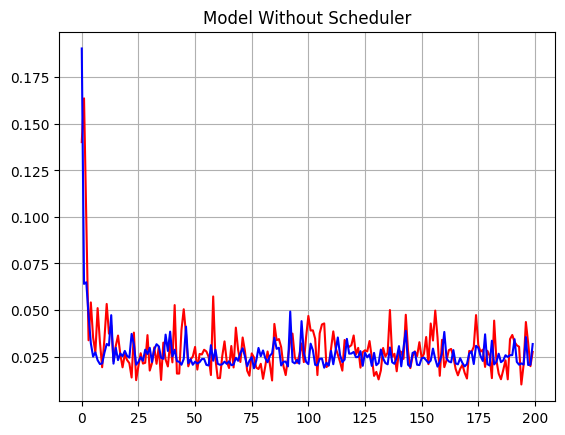

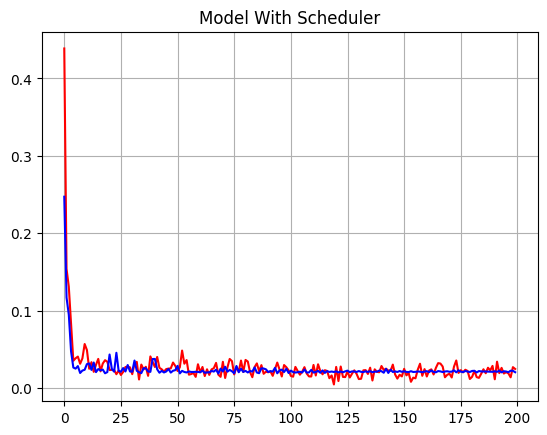

In [6]:
# Plot the first model's performance
plt.plot(train_losses1, color='red', label='Training Loss')
plt.plot(val_losses1, color='blue', label='Validation Loss')
plt.title('Model Without Scheduler')
plt.grid()
plt.show()

# Plot the second model's performance
plt.plot(train_losses2, color='red', label='Training Loss')
plt.plot(val_losses2, color='blue', label='Validation Loss')
plt.title('Model With Scheduler')
plt.grid()
plt.show()